This project attempts to answer the question: **'Do red cards lead to more goals in a football match?'**

We mean more goals in general here: we might expect the team with the red card to get fewer
goals than we would have otherwise expected, and their opponent to get more, but the question
is whether these effects combined lead to more goals overall.

We will use two datasets: 'games.csv' which contains the information of 20,370 matches across 10 European leagues from 2018-2023, and 'events.csv' which contains the time of every red card and goal in each match.


In [4]:
#Load packages
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\16moc\python_env\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [5]:
#Load data
games = pd.read_csv('games.csv')
events = pd.read_csv('events.csv')

In [6]:
#Print some basic info about the datasets
print(f"Number of games = {games['game_id'].nunique()}")
print(f"Number of teams = {pd.unique(games[['home_team', 'away_team']].values.ravel()).shape[0]}")
print(f"Number of leagues = {games['competition'].nunique()}")
print(f"Number of games with red card = {events[events['type'] == 'red_card']['game_id'].nunique()}")
print(f"Number of games without red card = {games['game_id'].nunique() - events[events['type'] == 'red_card']['game_id'].nunique()}")
print(f"Date range: {games['date'].min()} to {games['date'].max()}")

red_card_counts = (events[events['type'] == 'red_card']
                   .groupby('game_id')
                   .size())
print(f"Games with multiple red cards: {(red_card_counts > 1).sum()}")

Number of games = 20370
Number of teams = 247
Number of leagues = 10
Number of games with red card = 3273
Number of games without red card = 17097
Date range: 2018-07-27 to 2023-06-04
Games with multiple red cards: 402


# Naive Approach

First let's start with a naive approach to the problem; we test if on average there are more goals when a red card has been awarded or when no red card has been awarded:

### Data Prep - this cell can be folded

In [4]:
#Create events dataset only containing red cards
red_events = (events[events['type'] == 'red_card']
             #incase multiple red cards - only care about first red card
             .sort_values('minute')
             .groupby('game_id')
             .first()
             .reset_index())

#Merge datasets
data = pd.merge(games, red_events[['game_id','minute']], on='game_id', how='left')
data['has_red'] = data['minute'].notna() #True/ False red cards column
data['total_goals'] = data['home_goals'] + data['away_goals']


goal_events = events[events['type'] == 'goal']
#Function to split games with red cards
def split_goals(row):
    #All match goals events
    match_goals = goal_events[goal_events['game_id'] == row['game_id']]
    #no. goals scored pre red card
    pre_goals  = (match_goals['minute'] <= row['minute']).sum()
    #no. goals scored post red card
    post_goals = (match_goals['minute'] >  row['minute']).sum()
    return pd.Series({'pre_goals': pre_goals, 'post_goals': post_goals})

red_games = data[data['has_red']].copy()
nored_games = data[data['has_red'] == False].copy()

nored_games = nored_games.drop(columns=['minute'])
red_games[['pre_goals','post_goals']] = red_games.apply(split_goals, axis=1)

#Calculate no. of minutes with/without red card
red_games['pre_mins']  = red_games['minute']
red_games['post_mins'] = 90 - red_games['minute']

nored_mins = len(nored_games) * 90
prered_mins = red_games['pre_mins'].sum()
postred_mins = red_games['post_mins'].sum()

nored_goals = nored_games['total_goals'].sum()
prered_goals = red_games['pre_goals'].sum()
postred_goals = red_games['post_goals'].sum()

### Naive Model

The naive model calculates (per 90 minutes):

$$
\text{Avg. No Red Card Goals} =
\frac{\text{\# Goals scored when no red card has been awarded}}
{\text{\# Minutes played when no red card has been awarded}} \times 90
$$

$$
\text{Avg. Red Card Goals} =
\frac{\text{\# Goals scored when a red card has been awarded}}
{\text{\# Minutes played when a red card has been awarded}} \times 90
$$

In [5]:
#Calculate naive goals per game with/ without red cards
red_avg_goals = (postred_goals / postred_mins) * 90
nored_avg_goals = ((prered_goals + nored_goals) / (prered_mins + nored_mins)) * 90

print(f'Red card averge goals (per 90): {red_avg_goals:.3f}')
print(f'No red card averge goals (per 90): {nored_avg_goals:.3f}')
print(f'Difference (per 90): {red_avg_goals - nored_avg_goals:.3f}')

Red card averge goals (per 90): 3.350
No red card averge goals (per 90): 2.617
Difference (per 90): 0.733


Given the large size of the dataset (20370 games), the naive approach clearly concludes that red cards cause more goals.

However, the naive approach comes with a lot of assumptions/ limitations, with some prominent ones being:

* Red cards are present at the end of games, when there is more likely to be more goals anyway due to teams pushing for a result/ opening up/ fatigue etc.
* Assumes games are equally comparable. Does not account for the league or teams playing in the game.
* Doesn't account for the game state at the time of the red card, high/ low scoring games are more likely to continue in that vein regardless of a red card.
* This dataset assumes that there is exactly 90 minutes played in each game with no added time, when in fact there is usually around 4-6 minutes added time at the end of each game. The naive approach doesn't account for this. E.g. here a red card in the 85th minute calculates 5 minutes played when in fact it is usually around 10 minutes, this seriously biases the average goals per game for red cards.
* Doesn't account for any uncertainty in its estimate.
* etc.

Therefore, we cannot trust this naive approach as a reliable solution for 'do red cards lead to more goals'. We have to use a method which can handle these limitations.



# Bayesian Hierarchical Model

To best deal with the limitations of the naive approach, we can implement a bayesian hierarchical model. 

We will use a Negative Binomial model to predict the the amount of goals $Y$ a team scores at a given time of a match which takes the form:

$$
Y_i \sim \text{NegBin}(\lambda_i, \alpha)
$$

$$
\begin{aligned}
\log(\lambda_i) =\;& \text{league}_l
+ \text{attack}_i
- \text{defense}_j
+ \text{home\_adv} \cdot I[i = home\_team] \\
&+ \beta_{\text{tempo}} (goals_i + goals_j) + \beta_{\text{lead}} (goals_i - goals_j) \\
&+ \delta_{\text{self}} \cdot I[red = i] + \delta_{\text{opponent}} \cdot I[red = j] \\
&+ \log(\text{minutes\_remaining})
\end{aligned}
$$

where:
* $i$ and $j$ are the two teams in a given match, we predict how many goals each will score.
* league_l is the average goals scored by a team in league $l$, it acts as a group-level intercept.
* attack_i and defense_j are random effects which denote how good each teams attack and defense are (Note: as this dataset only contains games in set leagues these numbers are relative to the leagues, e.g. Arsenal and Monaco may have the same attack effect - this does not mean that their attacks are equally good, it means their attacks are equally good relative to their respective leagues).
* Home advantage is a fixed effect that's represents the home teams statistical advantage for playing at home, we assume that this is the same accross teams and leagues.
* $\beta_{\text{tempo}}$ and $\beta_{\text{lead}}$ are coefficents for the amount of goals in the match and lead/ decifit respectively at a given time in a match. They simultaneously represent the 'game state'.
* We add $\log(\text{minutes\_remaining})$ to convert the model from predicting the rate of goals, to expected number of goals scored given how many minutes are left in the match.
* $\delta_{\text{self}}$ and $\delta_{\text{opponent}}$ are the effects of how many goals a team scores given either they recieve a red card or their opponent receives a red card respectively. Ultimately these are the effects we want to measure to answer the hypothesis.


We choose a Negative Binomial to measure this as goals are non-negative discrete events that occur over a fixed time period, and unlike Poisson it doesn't suffer from underdispersion.

We calculate this model using two stages:


## Stage 1 - Baseline Model

In the first stage, we calculate the baseline scoring model which contains the league, team and home advantage effects. We estimate these effects first as they are **time-invariant** factors, so we want to estimate them on the full 90 minutes of each game. The baseline model represents the scoring rate predicted of each team in a match **before the match begins**. We again use the NegativeBinomial distribution, it is denoted as:

$$
\begin{aligned}
\log(\lambda_i) =\;& \text{league}_l
+ \text{attack}_i
- \text{defense}_j
+ \text{home\_adv} \cdot I[i = home\_team]
- \log(90)
\end{aligned}
$$

### Data Prep - this cell can be folded

In [6]:
stage1_home = data.assign(
    team       = lambda df: df['home_team'],
    opponent   = lambda df: df['away_team'],
    goals      = lambda df: df['home_goals'],
    minutes    = 90,
    is_home    = 1,
)[['game_id', 'competition', 'team', 'opponent', 'goals', 'minutes', 'is_home']]

stage1_away = data.assign(
    team       = lambda df: df['away_team'],
    opponent   = lambda df: df['home_team'],
    goals      = lambda df: df['away_goals'],
    minutes    = 90,
    is_home    = 0,
)[['game_id', 'competition', 'team', 'opponent', 'goals', 'minutes', 'is_home']]

stage1_data = (pd.concat([stage1_home, stage1_away])
                 .reset_index(drop=True))

### Model

In [7]:
#Create a index (key) for each team
#League-team separate entities
#- eg Southamption Championship independent to Southamption Premier League
stage1_data['team_league']     = stage1_data['team']     + "_" + stage1_data['competition']
stage1_data['opponent_league'] = stage1_data['opponent'] + "_" + stage1_data['competition']
team_leagues = pd.unique(stage1_data[['team_league', 'opponent_league']].values.ravel())
tl_to_idx = {tl: idx for idx, tl in enumerate(team_leagues)}
stage1_data['team_idx']     = stage1_data['team_league'].map(tl_to_idx)
stage1_data['opponent_idx'] = stage1_data['opponent_league'].map(tl_to_idx)
n_teams = len(team_leagues)


#Create index for each league
competitions = pd.unique(stage1_data['competition'])
comp_to_idx  = {comp: idx for idx, comp in enumerate(competitions)}
stage1_data['comp_idx'] = stage1_data['competition'].map(comp_to_idx)
n_comps = len(competitions)

#Give names to pandas columns as numpy arrays for convience in hierarchical model
goals_obs    = stage1_data['goals'].values
team_idx     = stage1_data['team_idx'].values
opponent_idx = stage1_data['opponent_idx'].values
comp_idx     = stage1_data['comp_idx'].values

#Convert from binary to integers
is_home      = stage1_data['is_home'].values.astype(int)

In [8]:
with pm.Model() as stage1_model:
    #League effect
    #mean of 0.3 => 1.3 goals per game mean
    mu_league    = pm.Normal("mu_league", mu=0.3, sigma=0.3)
    #Exponential as std needs to be positive
    sigma_league = pm.Exponential("sigma_league", lam=15)
    league_effect = pm.Normal("league_effect", mu=mu_league, 
                              sigma=sigma_league, shape=n_comps)

    #Team effects
    #lam=5 => approx. 0.3 std between teams
    sigma_attack = pm.Exponential("sigma_attack", lam=5)
    sigma_defend = pm.Exponential("sigma_defend", lam=5)
    attack = pm.Normal("attack", mu=0, sigma=sigma_attack, shape=n_teams)
    defend = pm.Normal("defend", mu=0, sigma=sigma_defend, shape=n_teams)

    #Home advantage
    #expect home advantage to be positive
    home_adv = pm.Normal("home_adv", mu=0.1, sigma=0.3)

    #Negative binomial overdispersion parameter
    alpha = pm.Exponential("alpha", lam=0.5)

In [9]:
with stage1_model:
    log_lambda = (
        league_effect[comp_idx]
        + attack[team_idx]
        - defend[opponent_idx]
        + home_adv * is_home
    )
    pm.NegativeBinomial("goals_pred", 
                        mu=pm.math.exp(log_lambda), alpha=alpha, observed=goals_obs)

#Use Variational approximation
#- although it is an approxiamtion it significantly improves on compute time
with stage1_model:
    approx_stage1 = pm.fit(
        n=5000,
        method="advi",
        obj_optimizer=pm.adam(learning_rate=0.01),
        callbacks=[pm.callbacks.CheckParametersConvergence(tolerance=0.01)],
        random_seed=123
    )

Output()

### Model Diagnostics

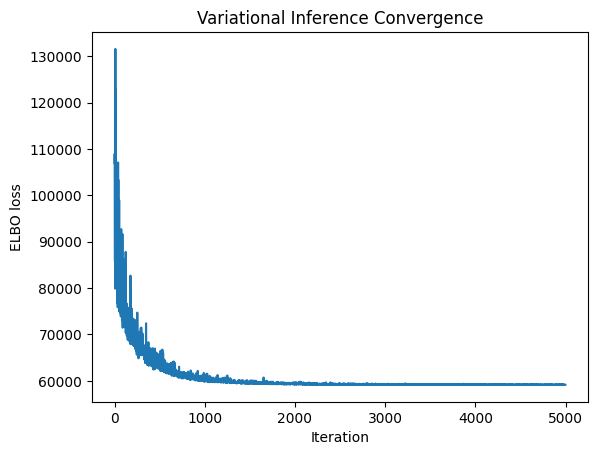

In [10]:
#Plot convergence
plt.plot(approx_stage1.hist)
plt.ylabel("ELBO loss")
plt.xlabel("Iteration")
plt.title("Variational Inference Convergence")
plt.show()

In [11]:
#Take a sample of 500 from posterior
np.random.seed(123)
post = approx_stage1.sample(500)

#Caclulate effect averages using posterior sample
home_adv_mean = post.posterior["home_adv"].values.mean()
alpha_mean = post.posterior["alpha"].values.mean()
league_means = post.posterior["league_effect"].values.mean(axis=(0,1))
attack_means = post.posterior["attack"].values.mean(axis=(0,1))
defend_means = post.posterior["defend"].values.mean(axis=(0,1))

#Print effects
print(f"Home Advantage = {home_adv_mean:.3f}")
print(f"Alpha = {alpha_mean:.3f}")
print("\nLeague Effects:")
for comp, idx in comp_to_idx.items():
    print(f"  {comp:<35} {league_means[idx]:.3f}  (avg goals/game: {np.exp(league_means[idx]):.2f})")

#Only print premier league teams (still examine effects withoit printing all 326 teams)
print("\nPremier League Team Effects:")
print(f"{'Team':<30} {'Attack':>10} {'Defend':>10}")
print("-" * 52)
pl_teams = [(tl, idx) for tl, idx in tl_to_idx.items()
            if 'Premier League' in tl]
pl_teams_sorted = sorted(pl_teams, key=lambda x: attack_means[x[1]], reverse=True)
for tl, idx in pl_teams_sorted:
    team_name = tl.replace("_Premier League, England", "")
    print(f"  {team_name:<28} {attack_means[idx]:>10.3f} {defend_means[idx]:>10.3f}")

Home Advantage = 0.188
Alpha = 56.726

League Effects:
  Ligue 2, France                     0.057  (avg goals/game: 1.06)
  2. Bundesliga, Germany              0.246  (avg goals/game: 1.28)
  Championship, England               0.106  (avg goals/game: 1.11)
  League One, England                 0.141  (avg goals/game: 1.15)
  League Two, England                 0.083  (avg goals/game: 1.09)
  Premier League, England             0.154  (avg goals/game: 1.17)
  Ligue 1, France                     0.117  (avg goals/game: 1.12)
  Primera, Spain                      0.097  (avg goals/game: 1.10)
  Serie A, Italy                      0.177  (avg goals/game: 1.19)
  1. Bundesliga, Germany              0.233  (avg goals/game: 1.26)

Premier League Team Effects:
Team                               Attack     Defend
----------------------------------------------------
  Manchester City                   0.640      0.455
  Liverpool                         0.498      0.387
  Tottenham Hotspur    

Output()

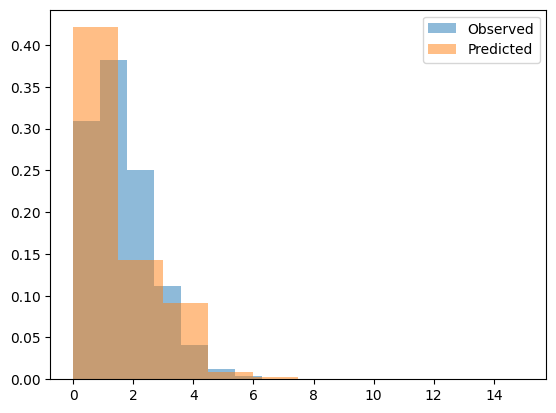

In [12]:
#Sample the posterior predictive
with stage1_model:
    ppc = pm.sample_posterior_predictive(post, random_seed = 123)

#Team predicted vs observed goal distribution
predicted = ppc.posterior_predictive["goals_pred"].values.flatten()
plt.hist(goals_obs, bins=10, alpha=0.5, label="Observed", density=True)
plt.hist(predicted, bins=10, alpha=0.5, label="Predicted", density=True)
plt.legend()
plt.show()

/tmp/ipykernel_12565/3713065783.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


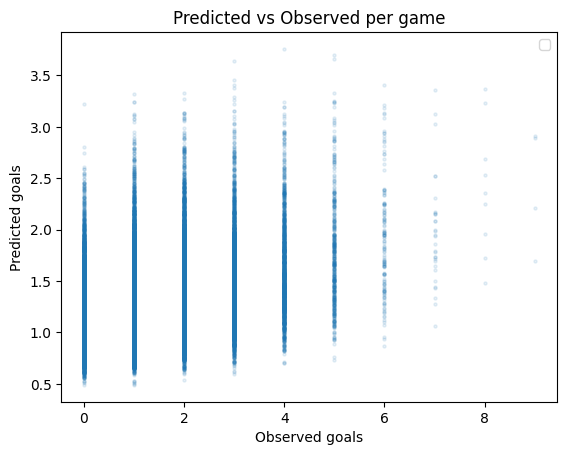

In [13]:
#Team predicted vs observed goal distribution per game
predicted_mean = ppc.posterior_predictive["goals_pred"].values.mean(axis=(0,1))
plt.scatter(goals_obs, predicted_mean, alpha=0.1, s=5)
plt.xlabel("Observed goals")
plt.ylabel("Predicted goals")
plt.title("Predicted vs Observed per game")
plt.legend()
plt.show()

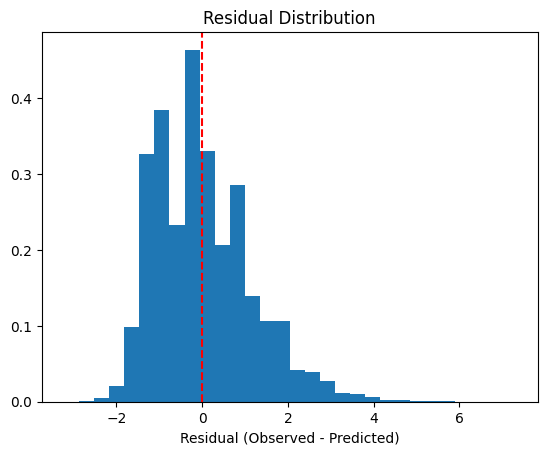

Mean residual: 0.017
Std residual:  1.126


In [14]:
#Plot residuals
residuals = goals_obs - predicted_mean

plt.hist(residuals, bins=30, density=True)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Residual (Observed - Predicted)")
plt.title("Residual Distribution")
plt.show()

print(f"Mean residual: {residuals.mean():.3f}")
print(f"Std residual:  {residuals.std():.3f}")

In [15]:
#Sanity check - check that the baseline model is producing sensible results
#Should be close to the actual average of goals scored
predicted_goals = np.exp(
    league_means[comp_idx]
    + attack_means[team_idx]
    - defend_means[opponent_idx]
    + home_adv_mean * is_home
)

print("Baseline Model Sanity Check")
print(f"Observed  mean:{goals_obs.mean():.3f}")
print(f"Predicted mean:{predicted_goals.mean():.3f}")
print(f"Predicted min:{predicted_goals.min():.3f}")
print(f"Predicted max:{predicted_goals.max():.3f}")
print(f"95% CI:[{np.percentile(predicted_goals, 2.5):.3f}, {np.percentile(predicted_goals, 97.5):.3f}]")

Baseline Model Sanity Check
Observed  mean:          1.326
Predicted mean:          1.303
Predicted min:           0.475
Predicted max:           3.649
95% CI:                 [0.775, 2.195]


Model diagnostics and posterior means of the baseline model look good - time to move to Stage 2!

## Stage 2  - Red Card Effects Model

Now, given our results from Stage 1 we can now go about calculating the full model using the posterior means of league, team and home advantage as fixed constants.

*Note: idealy we would sample from the posteriors of the league, team and home advantage random effects rather than using their means to keep Stage 2 fully Bayesian, however, this would add serious compute costs to the model. By using their posterior means we avoid this, although it will unestimate the uncertainty in the final model.*


Now we want to compute the predicted number of goals that will be scored at a given minute of a match, adding the 'game state' and red card effects.

Let's denote the time of the first red card as $\tau$. As $1 \leq \tau \leq 90$, it would be unfair to calculate the predicted number of goals scored for red card matches at the time $\tau$, and non-red card games at the start of the match. So account for this, we create a pseudo-$\tau$ variable for all non-red card matches, where pseudo-$\tau$ aims follow the same time distribution as $\tau$.

So then for our model, we calculate the predicted number of goals scored from time $\tau$ or pseudo-$\tau$, adding the red card effects $\delta_{\text{self}}$ and $\delta_{\text{opponent}}$ only to matches that start from $\tau$.

*Note: We only look at red cards between minutes 1 and 89, as the data is unable to account for 90 minute red cards accordingly (as it doesn't account for added time)*

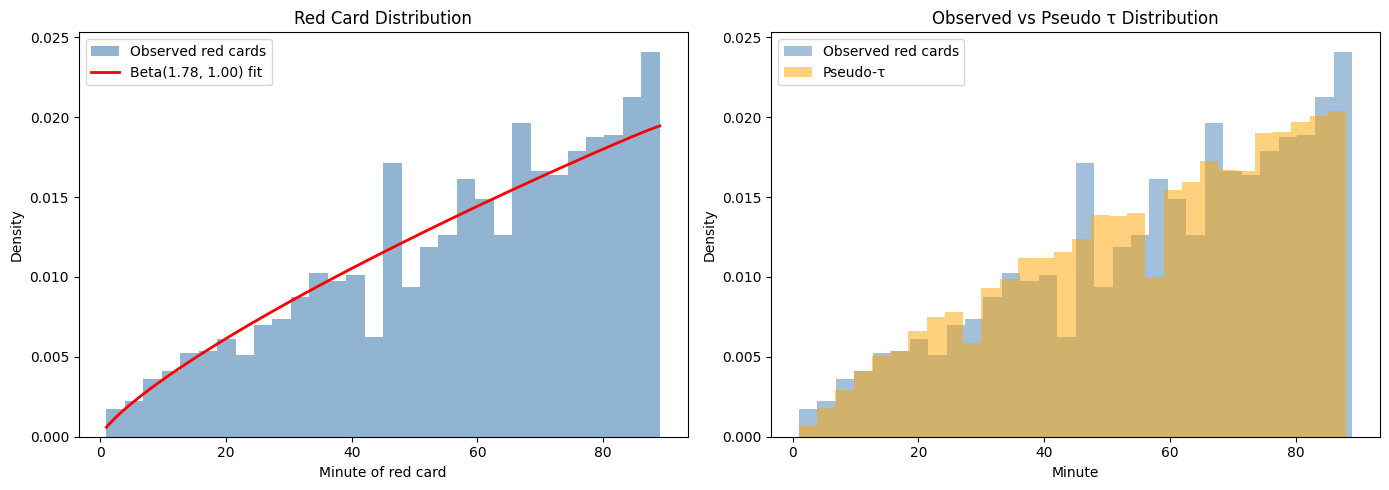

In [16]:
#Fit beta dist to tau
minutes_filtered = red_games[red_games['minute'] < 90]['minute']
minutes_scaled   = minutes_filtered / 90
a, b = beta_dist.fit(minutes_scaled, floc=0, fscale=1)[:2]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#Plot red card distribution by minute (1-89)
axes[0].hist(minutes_filtered, bins=30, density=True,
             alpha=0.6, color='steelblue', label='Observed red cards')
x_mins = np.linspace(1, 89, 200)
axes[0].plot(x_mins,
             beta_dist.pdf(x_mins/90, a, b) / 90,
             'r-', linewidth=2,
             label=f'Beta({a:.2f}, {b:.2f}) fit')
axes[0].set_xlabel('Minute of red card')
axes[0].set_ylabel('Density')
axes[0].set_title('Red Card Distribution')
axes[0].legend()

#Plot pseudo tau vs red cards
np.random.seed(42)
pseudo_tau = (beta_dist.rvs(a, b, size=len(nored_games)) * 88 + 1).astype(int)

axes[1].hist(minutes_filtered, bins=30, density=True,
             alpha=0.5, color='steelblue', label='Observed red cards')
axes[1].hist(pseudo_tau, bins=30, density=True,
             alpha=0.5, color='orange', label='Pseudo-τ')
axes[1].set_xlabel('Minute')
axes[1].set_ylabel('Density')
axes[1].set_title('Observed vs Pseudo τ Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

#Add pseudo-tau to no-red games table
nored_games['minute'] = pseudo_tau

### Data Prep - this cell can be folded

In [17]:
#Remove any 90th min red cards
red_games = red_games[red_games['minute'] < 90].reset_index(drop=True)

#Add red_card_self_home and red_card_self_away
red_events_side = (events[events['type'] == 'red_card']
                   .sort_values('minute')
                   .groupby('game_id')
                   .first()
                   .reset_index()[['game_id', 'side']]
                   .rename(columns={'side': 'red_side'}))

red_games = red_games.merge(red_events_side, on='game_id', how='left')
red_games['red_on_self_home'] = red_games['red_side'] == 'home'
red_games['red_on_self_away'] = red_games['red_side'] == 'away'
nored_games['red_on_self_home'] = False
nored_games['red_on_self_away'] = False

#Combine red_games and nored_games
all_games = pd.concat([red_games, nored_games]).reset_index(drop=True)

#Split goals by tau
goal_events = events[events['type'] == 'goal']
def split_goals_by_side(row):
    match_goals = goal_events[goal_events['game_id'] == row['game_id']]
    pre  = match_goals[match_goals['minute'] <= row['minute']]
    post = match_goals[match_goals['minute'] >  row['minute']]
    return pd.Series({
        'pre_home_goals':  (pre['side']  == 'home').sum(),
        'pre_away_goals':  (pre['side']  == 'away').sum(),
        'post_home_goals': (post['side'] == 'home').sum(),
        'post_away_goals': (post['side'] == 'away').sum(),
    })

all_games[['pre_home_goals', 
           'pre_away_goals',
           'post_home_goals', 
           'post_away_goals']] = all_games.apply(split_goals_by_side, axis=1)
all_games['post_mins'] = 90 - all_games['minute']

post_home = all_games.assign(
    team        = lambda df: df['home_team'],
    opponent    = lambda df: df['away_team'],
    goals       = lambda df: df['post_home_goals'],
    minutes     = lambda df: df['post_mins'],
    is_home     = 1,
    g_h         = lambda df: df['pre_home_goals'],
    g_a         = lambda df: df['pre_away_goals'],
    red_on_self = lambda df: df['red_on_self_home'],
    red_on_opp  = lambda df: df['red_on_self_away'],
)

post_away = all_games.assign(
    team        = lambda df: df['away_team'],
    opponent    = lambda df: df['home_team'],
    goals       = lambda df: df['post_away_goals'],
    minutes     = lambda df: df['post_mins'],
    is_home     = 0,
    g_h         = lambda df: df['pre_home_goals'],
    g_a         = lambda df: df['pre_away_goals'],
    red_on_self = lambda df: df['red_on_self_away'],
    red_on_opp  = lambda df: df['red_on_self_home'],
)

COLS = ['game_id', 'competition', 'team', 'opponent', 'goals', 'minutes',
        'is_home', 'g_h', 'g_a', 'red_on_self', 'red_on_opp', 'has_red']

stage2_data = (pd.concat([post_home, post_away]).reset_index(drop=True)[COLS])

### Model

In [18]:
#Game state - clip extreme values to prevent exploding values
stage2_data['g_tempo'] = np.clip(stage2_data['g_h'] + stage2_data['g_a'], 0, 5)
stage2_data['g_lead']  = np.clip(stage2_data['g_h'] - stage2_data['g_a'], -3, 3)

#Transfer fixed effects indices from stage 1
stage2_data['team_league']     = stage2_data['team']     + "_" + stage2_data['competition']
stage2_data['opponent_league'] = stage2_data['opponent'] + "_" + stage2_data['competition']
stage2_data['team_idx']     = stage2_data['team_league'].map(tl_to_idx)
stage2_data['opponent_idx'] = stage2_data['opponent_league'].map(tl_to_idx)
stage2_data['comp_idx']     = stage2_data['competition'].map(comp_to_idx)

#Fixed effects from stage 1
attack_fixed  = post.posterior["attack"].values.mean(axis=(0,1))
defend_fixed  = post.posterior["defend"].values.mean(axis=(0,1))
league_fixed  = post.posterior["league_effect"].values.mean(axis=(0,1))
home_fixed    = post.posterior["home_adv"].values.mean()

#Stage 2 indices
goals_obs_s2    = stage2_data['goals'].values
team_idx_s2     = stage2_data['team_idx'].values
opponent_idx_s2 = stage2_data['opponent_idx'].values
comp_idx_s2     = stage2_data['comp_idx'].values
is_home_s2      = stage2_data['is_home'].values.astype(int)
g_tempo_s2      = stage2_data['g_tempo'].values
g_lead_s2       = stage2_data['g_lead'].values
red_on_self_s2  = stage2_data['red_on_self'].values.astype(int)
red_on_opp_s2   = stage2_data['red_on_opp'].values.astype(int)
log_minutes_s2  = np.log(stage2_data['minutes'].values)

In [19]:
with pm.Model() as stage2_model:
    #Uninformative priors
    beta_tempo = pm.Normal("beta_tempo", mu=0, sigma=0.3)
    beta_lead  = pm.Normal("beta_lead",  mu=0, sigma=0.3)

    #Red card effects - uniformative
    delta_self = pm.Normal("delta_self", mu=0, sigma=0.5)
    delta_opp = pm.Normal("delta_opp", mu=0, sigma=0.5)

    #Overdispersion
    alpha = pm.Exponential("alpha", lam=0.5)

In [20]:
with stage2_model:
    baseline = (
        league_fixed[comp_idx_s2]
        + attack_fixed[team_idx_s2]
        - defend_fixed[opponent_idx_s2]
        + home_fixed * is_home_s2
        - np.log(90)  #rescale to per-minute rate
    )

    log_lambda = (
        baseline
        + beta_tempo * g_tempo_s2
        + beta_lead  * g_lead_s2
        + delta_self  * red_on_self_s2
        + delta_opp  * red_on_opp_s2
        + log_minutes_s2
    )

    pm.NegativeBinomial("goals_pred_s2", 
                        mu=pm.math.exp(log_lambda), alpha=alpha, observed=goals_obs_s2)

with stage2_model:
    approx_stage2 = pm.fit(
        n=5000,
        method="advi",
        obj_optimizer=pm.adam(learning_rate=0.01),
        callbacks=[pm.callbacks.CheckParametersConvergence(tolerance=0.01)],
        random_seed=123
    )


Output()

### Model Diagnostics

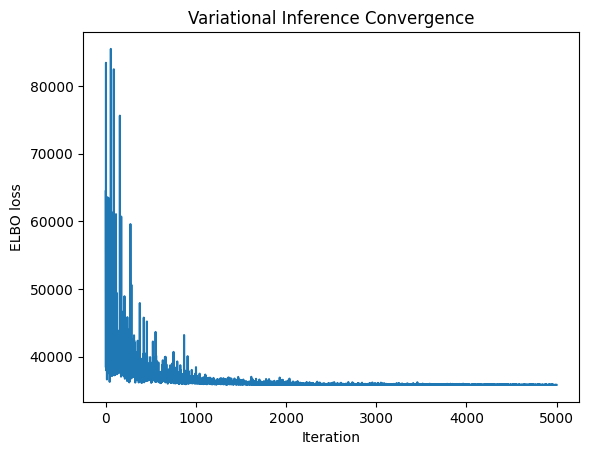

In [21]:
plt.plot(approx_stage2.hist)
plt.ylabel("ELBO loss")
plt.xlabel("Iteration")
plt.title("Variational Inference Convergence")
plt.show()

In [22]:
np.random.seed(123)
post_s2 = approx_stage2.sample(500)
with stage2_model:
    ppc_s2 = pm.sample_posterior_predictive(post_s2, random_seed=123)

Output()

In [30]:
#Print posterior averages
temp_mean = post_s2.posterior["beta_tempo"].values.mean(axis=(0,1))
lead_mean = post_s2.posterior["beta_lead"].values.mean(axis=(0,1))
delta_self_mean = post_s2.posterior["delta_self"].values.mean(axis=(0,1))
delta_opp_mean = post_s2.posterior["delta_opp"].values.mean(axis=(0,1))

print(f"beta_tempo = {temp_mean:.3f}")
print(f"beta_lead = {lead_mean:.3f}")
print(f"delta_self = {delta_self_mean:.3f}")
print(f"delta_opp = {delta_opp_mean:.3f}")

beta_tempo = 0.092
beta_lead = 0.001
delta_self = -0.471
delta_opp = 0.530


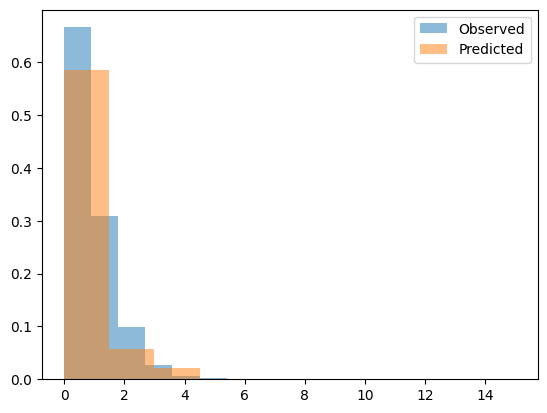

In [23]:
#Team predicted vs observed goal distribution
predicted = ppc_s2.posterior_predictive["goals_pred_s2"].values.flatten()
plt.hist(goals_obs_s2, bins=10, alpha=0.5, label="Observed", density=True)
plt.hist(predicted, bins=10, alpha=0.5, label="Predicted", density=True)
plt.legend()
plt.show()

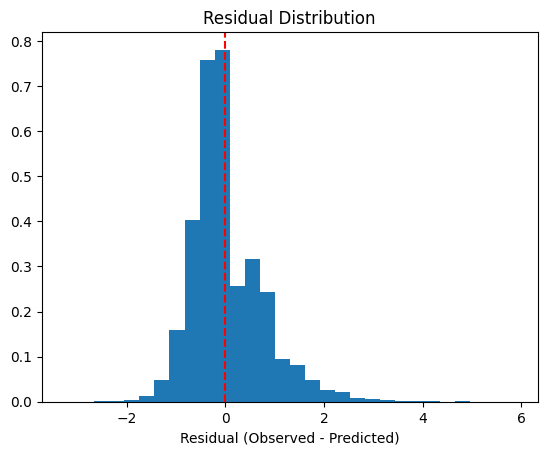

Mean residual: 0.021
Std residual:  0.735


In [24]:
predicted_mean = ppc_s2.posterior_predictive["goals_pred_s2"].values.mean(axis=(0,1))
residuals = goals_obs_s2 - predicted_mean

plt.hist(residuals, bins=30, density=True)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Residual (Observed - Predicted)")
plt.title("Residual Distribution")
plt.show()

print(f"Mean residual: {residuals.mean():.3f}")
print(f"Std residual:  {residuals.std():.3f}")

# Conclusion

delta_self  mean: -0.471 95% CI: [-0.544, -0.399]
delta_opp  mean: 0.530  95% CI: [0.485, 0.575]
total      mean: 0.059  95% CI: [-0.026, 0.148]

On rate scale:
Carded team scores on average:  0.624x their normal rate
Opponent scores on average:     1.699x their normal rate
Total goals on average:     1.061x the normal rate

P(red cards reduce carded team scoring):  1.000
P(red cards increase opponent scoring):   1.000
P(red cards increase total goals):        0.904


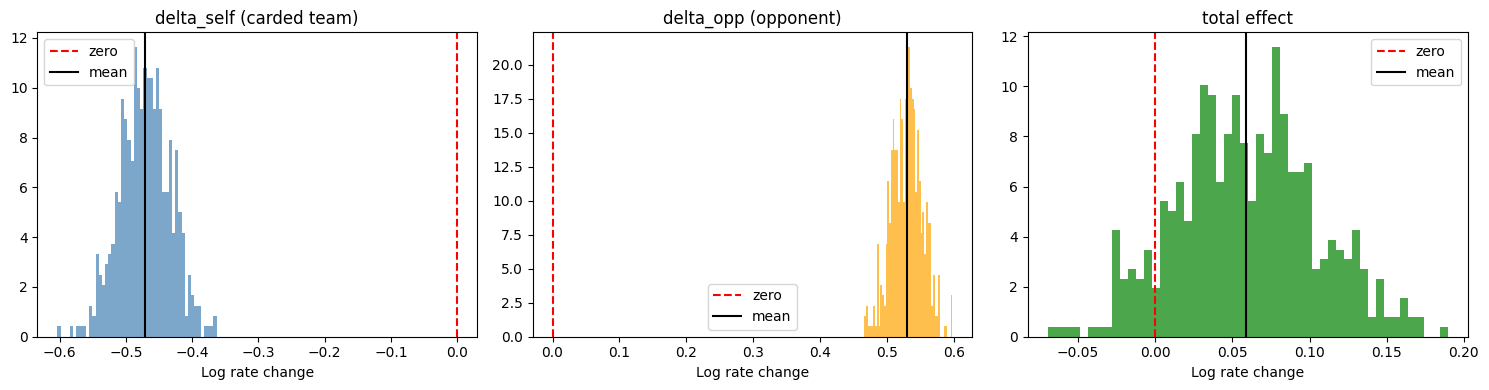

In [28]:
#Print red card effects
delta_self_samples = post_s2.posterior["delta_self"].values.flatten()
delta_opp_samples = post_s2.posterior["delta_opp"].values.flatten()
total_effect      = delta_self_samples + delta_opp_samples

print(f"delta_self  mean: {delta_self_samples.mean():.3f} 95% CI: [{np.percentile(delta_self_samples, 2.5):.3f}, {np.percentile(delta_self_samples, 97.5):.3f}]")
print(f"delta_opp  mean: {delta_opp_samples.mean():.3f}  95% CI: [{np.percentile(delta_opp_samples, 2.5):.3f}, {np.percentile(delta_opp_samples, 97.5):.3f}]")
print(f"total      mean: {total_effect.mean():.3f}  95% CI: [{np.percentile(total_effect, 2.5):.3f}, {np.percentile(total_effect, 97.5):.3f}]")

print(f"\nOn rate scale:")
print(f"Carded team scores on average:  {np.exp(delta_self_samples.mean()):.3f}x their normal rate")
print(f"Opponent scores on average:     {np.exp(delta_opp_samples.mean()):.3f}x their normal rate")
print(f"Total goals on average:     {np.exp(total_effect.mean()):.3f}x the normal rate")


print(f"\nP(red cards reduce carded team scoring):  {(delta_self_samples < 0).mean():.3f}")
print(f"P(red cards increase opponent scoring):   {(delta_opp_samples > 0).mean():.3f}")
print(f"P(red cards increase total goals):        {(total_effect > 0).mean():.3f}")

#Red cards Posterior Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, samples, title, color in zip(
    axes,
    [delta_self_samples, delta_opp_samples, total_effect],
    ['delta_self (carded team)', 'delta_opp (opponent)', 'total effect'],
    ['steelblue', 'orange', 'green']
):
    ax.hist(samples, bins=50, density=True, alpha=0.7, color=color)
    ax.axvline(0, color='red', linestyle='--', label='zero')
    ax.axvline(samples.mean(), color='black', linestyle='-', label='mean')
    ax.set_title(title)
    ax.set_xlabel('Log rate change')
    ax.legend()

plt.tight_layout()
plt.show()

Therefore, from the results above we can conclude that:

* A team receiving a red card results in a certain reduction of scoring goals on average.
* An opponent receiving a red card results in a certain increase of scoring goals on average.
* In terms of total goals in a match, these two effects approximately cancel out, with the opponent effect slightly dominating.

In conclusion, based on the data in this dataset, **red cards do seem to lead to more goals**, with a 90.4% posterior probability. Although it is only predicted to increase very marginally (1.061x the normal rate).

However, as the total goals estimate includes 0 in its 95% credible interval, **we cannot conclusively claim this at a conventional statistical significance level**.

## Limitations

There are some limitations in this experiment which should be acknowledged:

**Fundamental Limitations:** There are some limitations which we cannot control:
* Red cards are not random effects as we have assumed here, they are more likely to occur in intense games or when a team is already under pressure. This is something that we can't statistically account for.
* The data does not include added (injury) time, this means that we cannot accurately examine matches where a red card occurs in the 90th minute. As there is no way of knowing if it happened at the start/ end of added time.
* This data only includes goals and red cards as in-game data, we cannot include in the model possession, shots, expected goals etc. to make a more informed decision.

**Computational Trade-Offs**: Due to the complexity of the model and size of the dataset, we took some shortcuts along the way in order to control the computation costs of the model, these cause the following comprises:
* By using the posterior means of league, team and home advantage effects rather than sampling them our model is not fully Bayesian. This means that our final results **underestimate uncertainty**, as we do not account for the uncertainty of the estimates of the league, team and home advantage effects.
* By using variational approximation instead of MCMC, our model is **approximated not sampled**, meaning it is less accurate.
* Variational approximation also statistically **underestimates uncertainty** of our parameters. 

**Model Limitations:** These are controllable limitations which we have overlooked in the model for model simplicity, further work on this topic could include incorporating these factors.
* The model doesn't account for multiple red cards in the same game, it only looks at the first red card.
* We assume that our baseline model is stationary, which it is clearly not. The strength of a teams attack or defense changes over time which this model does not account for. Even home advantage as an effect changed post-COVID due to the absence of crowds.
* The model assumes that a team has an equal probability of scoring each minute of the game, when in reality more goals usually occur later in games. 